In [73]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL.ImImagePlugin import number
from PIL.ImageColor import colormap
from matplotlib import rcParams
from matplotlib.pyplot import tick_params


In [74]:
'''
   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student", "blue-collar","self-employed","retired","technician","services")
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric)
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")
'''

'\n   Input variables:\n   # bank client data:\n   1 - age (numeric)\n   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student", "blue-collar","self-employed","retired","technician","services")\n   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)\n   4 - education (categorical: "unknown","secondary","primary","tertiary")\n   5 - default: has credit in default? (binary: "yes","no")\n   6 - balance: average yearly balance, in euros (numeric)\n   7 - housing: has housing loan? (binary: "yes","no")\n   8 - loan: has personal loan? (binary: "yes","no")\n   # related with the last contact of the current campaign:\n   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")\n  10 - day: last contact day of the month (numeric)\n  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")\n  12 - dura

In [75]:
plt.rcParams.update({
'figure.dpi': 100,
'savefig.dpi': 300,
'figure.figsize': (20, 10),

'font.family': 'serif',
'font.size': 12,
'axes.titlesize': 12,
'axes.labelsize': 12,
'xtick.labelsize': 10,
'ytick.labelsize': 10,

'axes.spines.top': False,
'axes.spines.right': False,
'axes.grid': True,
'grid.alpha': 0.4,
'grid.linestyle': '--',
'axes.edgecolor': '#333333',

'lines.linewidth': 2,
'patch.edgecolor': 'none',

'axes.prop_cycle': plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
})

## 1. WSTĘPNA ANALIZA DANTCH

### 1.1 *Wczytanie i podstawowy opis danych:*

In [76]:
df = pd.read_csv('data/bank_marketing_dataset.csv', sep = ';')

In [77]:
#W razie problemów z wczytaniem pliku:
'''
from sklearn.datasets import fetch_openml

dataset = fetch_openml(data_id=1461, as_frame=True)
df = dataset.frame
col_names = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact',
 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
df.columns = col_names
'''

"\nfrom sklearn.datasets import fetch_openml\n\ndataset = fetch_openml(data_id=1461, as_frame=True)\ndf = dataset.frame\ncol_names = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact',\n 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']\ndf.columns = col_names\n"

In [78]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Na początku pozbywamy się zmiennej DURATION, ponieważ w momencie wnioskowania modelu nie będziemy znali czasu trwania rozmowy**

In [79]:
df.drop(columns='duration', inplace=True)

**Kodujemy również zmienne binarne jako integery**

In [80]:
col_names = df.columns.to_list()
col_names

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  campaign   45211 non-null  int64
 12  pdays      45211 non-null  int64
 13  previous   45211 non-null  int64
 14  poutcome   45211 non-null  str  
 15  y          45211 non-null  str  
dtypes: int64(6), str(10)
memory usage: 5.5 MB


In [82]:
num_cols = df.select_dtypes(include='number').columns.to_list()
len(num_cols)

6

In [83]:
cat_cols = df.select_dtypes(include='string').columns.to_list()
len(cat_cols)

10

In [84]:
n = len(df)
n

45211

**Nasz pierwotny zbiór zawiera 45211 obserwacji w tym każda zawiera 15 cech objaśniających i jedną binarną zmienną celu**

### 1.2. *Analiza brakujących wartości:*

**Znalizując df.info() mogłoby się wydawać, że nie mamy braków w danych, jednak musimy obsłużyć wartości "unknown".**

In [85]:
unknowns = {
    name: round(len(df[df[name].astype(str).str.lower() == 'unknown']) / n, 3)
    for name in col_names
    if (df[name].astype(str).str.lower() == 'unknown').any()
}
print(unknowns)

{'job': 0.006, 'education': 0.041, 'contact': 0.288, 'poutcome': 0.817}


In [86]:
for col in unknowns.keys():
    print(df[col].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


In [87]:
df[df['poutcome'] == 'unknown'][['pdays', 'poutcome']].value_counts()

pdays  poutcome
-1     unknown     36954
 98    unknown         1
 168   unknown         1
 188   unknown         1
 416   unknown         1
 528   unknown         1
Name: count, dtype: int64

**Ze względu na małych odsetek braków w zmiennych JOB i EDUCATION decydujemy się zastąpić wartości brakujące modą. Mamy też do czynienia z nielosowymi brakami w zmiennych: CONTACT i PUOTCOME, gdzie brak danych oznacza klienta, który nie grał udziału w zeszłej kampanii (z wyjątkiem paru wyjątków, gdzie obsługujemy medianą). Nie usuwamy tych obserwacji, ponieważ mogą nieść istotną informację dla modelu.**

In [88]:
mode_job = df.job.mode()[0]
mode_education = df.education.mode()[0]

df['job'] = df['job'].replace('unknown', mode_job)
df['education'] = df['education'].replace('unknown', mode_education)

print(len(df[df['education'] == 'unknown']))
print(len(df[df['job'] == 'unknown']))

0
0


In [89]:
mask = (df['contact'] == 'unknown') & (df['pdays'] != -1)
df.loc[mask, 'contact'] = df['contact'].mode()[0]
print(df[df['contact'] == 'unknown'][['contact', 'pdays']].value_counts())

contact  pdays
unknown  -1       12950
Name: count, dtype: int64


In [90]:
mask = (df['poutcome'] == 'unknown') & (df['pdays'] != -1)
df.loc[mask, 'pdays'] = df['pdays'].mode()[0]
print(df[df['poutcome'] == 'unknown'][['poutcome', 'pdays']].value_counts())

poutcome  pdays
unknown   -1       36959
Name: count, dtype: int64


In [91]:
mask = (df['pdays'] == -1) & (df['previous'] != 0)
df.loc[mask, 'previous'] = 0

**W celu pozbycia się obserwacji odstających stosujemy metodę miedzykwadrtylową IQR:**

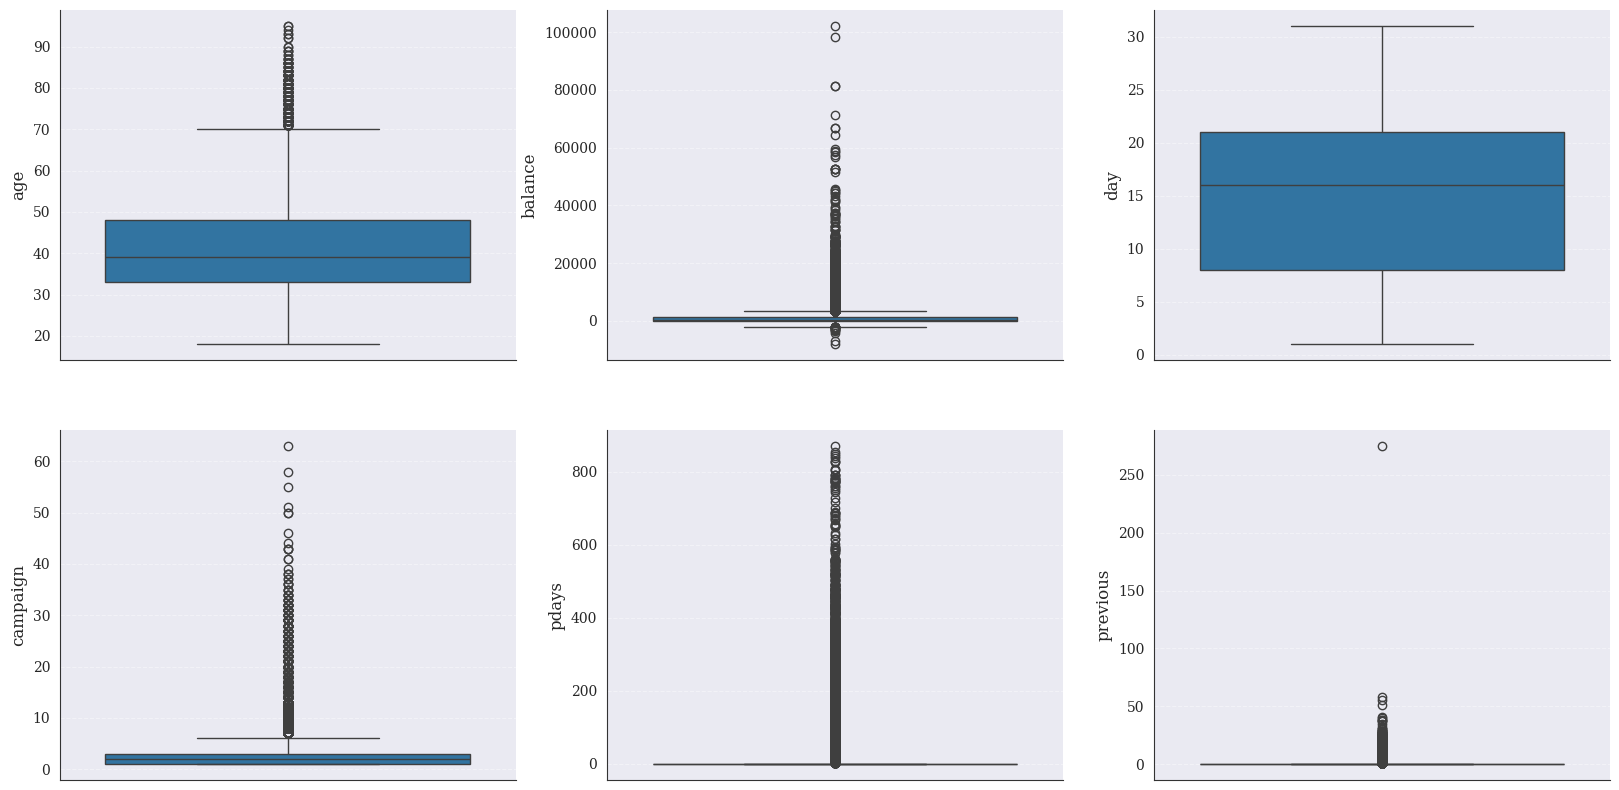

In [92]:
fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
plt.show()

In [93]:
def get_outlier_ranges(df, cols, multip=1.5):
    non_out_ranges = dict()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + multip*IQR
        lower = Q1 - multip*IQR
        non_out_ranges[col] = (lower, upper)
    return non_out_ranges

def get_outlier_info(df, col, lower, upper):
    mask = (df[col] > upper) | (df[col] < lower)
    n_outliers = sum(mask)
    percentage = n_outliers / n
    print(f"{col} [{lower}, {upper}]: {n_outliers} outliers - {(percentage):.3f} of pop")


In [94]:
non_out_dict = get_outlier_ranges(df, num_cols)
for col in num_cols:
    lower, upper = non_out_dict[col]
    get_outlier_info(df, col, lower, upper)

age [10.5, 70.5]: 487 outliers - 0.011 of pop
balance [-1962.0, 3462.0]: 4729 outliers - 0.105 of pop
day [-11.5, 40.5]: 0 outliers - 0.000 of pop
campaign [-2.0, 6.0]: 3064 outliers - 0.068 of pop
pdays [-1.0, -1.0]: 8252 outliers - 0.183 of pop
previous [0.0, 0.0]: 8252 outliers - 0.183 of pop


**Ze względu na dużą prawoskońsność w naszych danych decydujemy się nie wykorzysywać metody IQR - spowodowałoby to pozbycie się zbyt dużej liczby obserwacji. Zamiast tego skorzystamy z metody winsoryzacji na poziomie 0.5% i 99.5% - pozwoli nam to "przytrymować" wartości skrajne powstałe w wyniku szumu bądź błędu pomiaru, pozostawiając tym samym wszystkie deficytowe obserwacje klasy pozytywnej zmiennej y. Zmiennej DAY nie bierzemy pod uwagę w tym procesie bo nie zawiera ona wartości odstających.**

In [95]:
with_outliers = num_cols[:]
with_outliers.remove('day')
for col in with_outliers:
    print("Zakres przed trymowaniem:")
    print(f"{col}: [{np.min(df[col])}, {np.max(df[col])}]")
    per_05 = int(df[col].quantile(0.005))
    per_995 = int(df[col].quantile(0.995))
    df.loc[df[col] > per_995, col] = per_995
    df.loc[df[col] < per_05, col] = per_05
    print("Zakres po trymowaniu:")
    print(f"{col}: [{np.min(df[col])}, {np.max(df[col])}]")

Zakres przed trymowaniem:
age: [18, 95]
Zakres po trymowaniu:
age: [22, 77]
Zakres przed trymowaniem:
balance: [-8019, 102127]
Zakres po trymowaniu:
balance: [-867, 18014]
Zakres przed trymowaniem:
campaign: [1, 63]
Zakres po trymowaniu:
campaign: [1, 21]
Zakres przed trymowaniem:
pdays: [-1, 871]
Zakres po trymowaniu:
pdays: [-1, 408]
Zakres przed trymowaniem:
previous: [0, 275]
Zakres po trymowaniu:
previous: [0, 12]


### 1.4. *Podstawowe statystyki*

In [96]:
df.describe().round(2)

,age,balance,day,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.92,1311.59,15.81,2.73,39.51,0.54
std,10.53,2460.70,8.32,2.80,96.82,1.59
min,22.00,-867.00,1.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,3.00,-1.00,0.00
max,77.00,18014.00,31.00,21.00,408.00,12.00


In [97]:
df['y'] = np.where(df['y'] == 'yes', 1, 0)

In [98]:
skewness = df[num_cols].skew()
print(skewness)

age         0.632358
balance     3.719321
day         0.093079
campaign    3.454159
pdays       2.365321
previous    4.255373
dtype: float64


**Zgodnie z wcześniejszymi wykresami kilka zmiennych wykazuje silną prawoskośność >> 1.**

**Badamy zmienność naszych zmiennych ciągłych za pomocą współczynnika zmienności:**

In [99]:
cv = df[num_cols].apply(lambda x: x.std() / x.mean())
print(cv)

age         0.257320
balance     1.876114
day         0.526525
campaign    1.026548
pdays       2.450364
previous    2.916077
dtype: float64


**Badamy zmienność naszych zmiennych kategorycznych za pomocą entropi:**

In [100]:
for col in cat_cols:
    print(f"{col}: {(stats.entropy(df[col].value_counts(normalize=True)) / (np.log2(len(df[col].value_counts())))):.3f}")

job: 0.604
marital: 0.575
education: 0.614
default: 0.090
housing: 0.687
loan: 0.440
contact: 0.514
month: 0.568
poutcome: 0.325
y: 0.361


In [101]:
df['default'].value_counts(normalize=True)

default
no     0.981973
yes    0.018027
Name: proportion, dtype: float64

In [102]:
df.drop(columns='default', inplace=True)
col_names = df.columns.to_list()

In [103]:
num_cols = df.select_dtypes('number').columns.to_list()

In [104]:
num_cols

['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'y']

**Wszystie nasze zmienne (za wyjątkiem zmiennej DEFAULT) mają dostatecznie dużą zmienność. Biorąc pod uwagę dodatkowy konflikt wizerunkowo-etyczny banku, który nie powinien oferować lokaty osobom z którymi toczy spór prawny, decydujemy się na usunięcie zmiennej DEFAULT. Osoby niewypłacalne, przed trafieniem do modelu powinny zostać odrzucone z kampanii przy pomocy filtrów biznesowych.**

In [105]:
target_values = df['y'].value_counts(normalize=True)
target_values

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

**Mamy do czynienia z silnym niezbalanosowaniem zmiennej celu.
Dlatego skorzystamy z metody oversamplingu, w celu możliwie optymalnego wykorzystania obserwacji pozytywnych**

### 1.5. *Wstępne wnioski*

- Znaczna część naszych cech ma silnie prawostronny rozkład. Z tego powodu jako nasz model decydujemy się wykorzystać algorytm drzewa losowego, który jest odporny na wartości skrajne i skośność rozkładu. Oszczędzi nam to dodatkowo pracy w kwestii transforamacji zmiennych, a dodatkowo sam model będzie dobrze wyjaśnialny - będziemy w stanie wskazać czynniki, które w największym stopniu wpłynęły na decyzje modelu, co jest wyjąstkowo porządane w sektorze bankowym. Dodatkowo liczymy, że drzewo zgrabnie "podzieli" klientów na tych którzy brali udział w poprzedniej kampanii i na tych co udziału nie brali.
- Aby zbudować model oparty na tej metodzie będziemy musieli zakodować nasze zmienne kategoryczne stosując one-hot-encoding
 - Niezbalansowana zmienna celu dodatkowo wymusza na nas zastosowanie metodę nadpróbkowania klasy mnieszościowej.

**********************************

## 2. WIZUALIZACJE

### 2.1. *Wizualizacje rozkładów*

In [106]:
df_numeric = df[num_cols]
df_numeric.drop(columns='y', inplace=True)

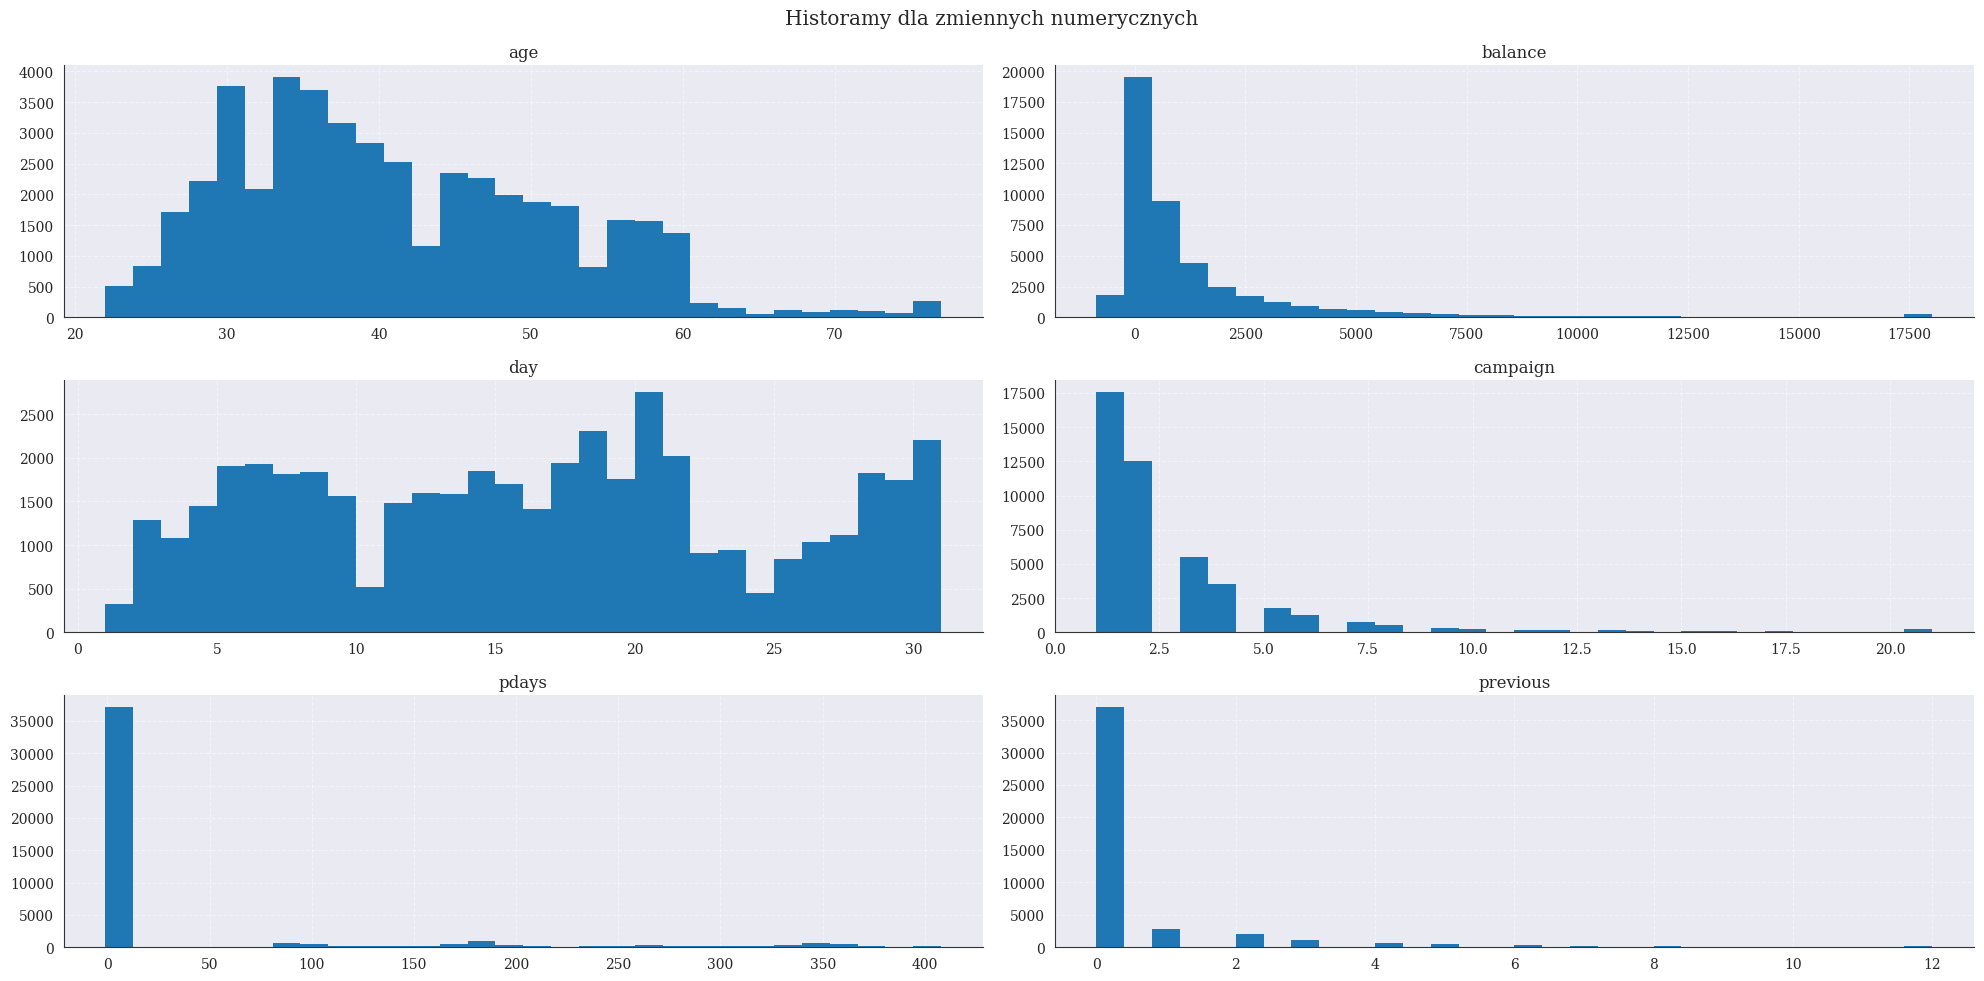

In [107]:
fig, axes = plt.subplots(3, 2)
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.hist(df_numeric[num_cols[i]], bins=30)
    ax.set_title(num_cols[i])
    ax.grid(True, alpha=0.5)

plt.suptitle("Historamy dla zmiennych numerycznych")
plt.tight_layout()
plt.show()

In [108]:
df.select_dtypes(include='number').kurt()

age          0.000649
balance     17.474819
day         -1.059897
campaign    15.476343
pdays        4.373355
previous    21.505205
y            3.681142
dtype: float64

Histogramy naszych danych liczbowych potwierdzają wcześniejsze wnioski o prawoskońności naszych danych. Zmienna age chartekteryzuje się rozkładem mezokuruktycznym (kurt~0)

In [109]:
df_categorical = df.drop(columns=num_cols)

In [110]:
cat_cols = df_categorical.columns.to_list()

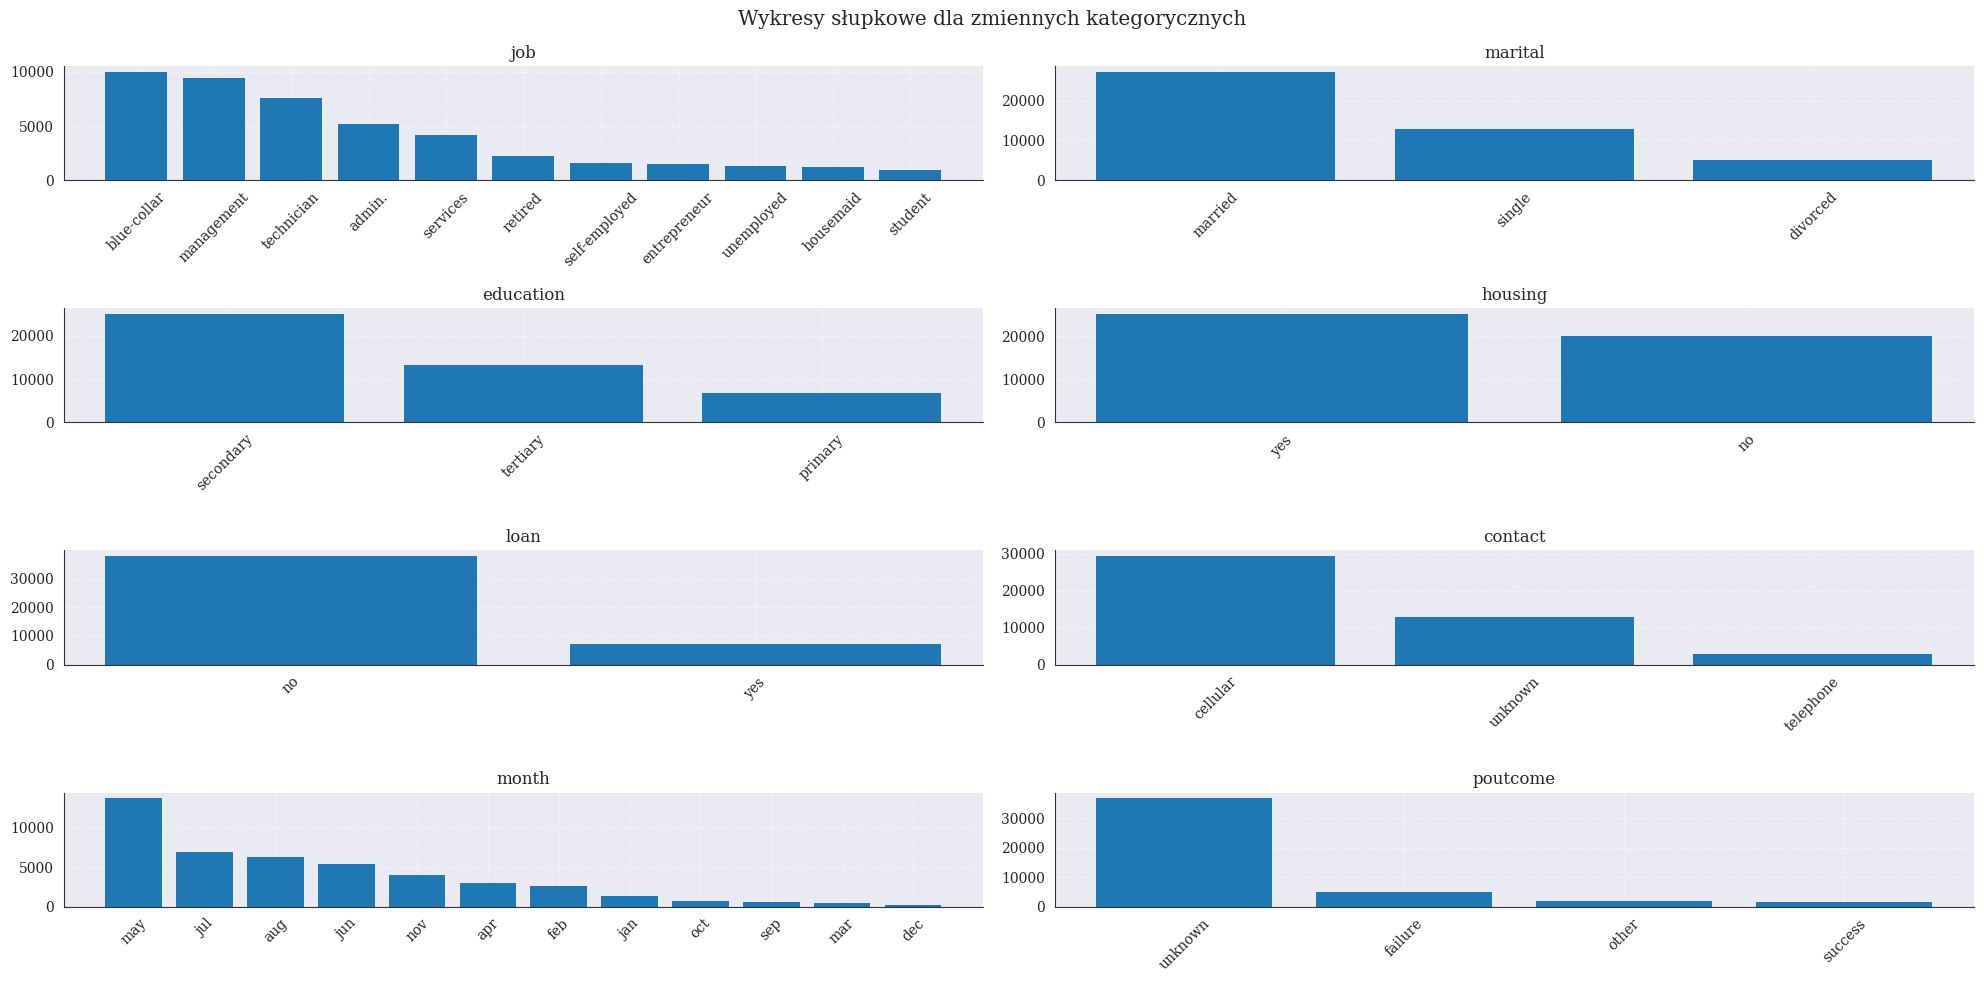

In [111]:
fig, axes = plt.subplots(4, 2)
axes = axes.flatten()

for i, ax in enumerate(axes):
    counts = df[cat_cols[i]].value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(cat_cols[i])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.5)

plt.suptitle("Wykresy słupkowe dla zmiennych kategorycznych")
plt.tight_layout()
plt.show()

Wykresy zmiennych kategorycznych nają dam dobry pogłąd na ogólny rozkad tych zmiennych. Do rozkładów wartych odnotowania jest fakt, że analizawane przypadki kampanii miałe w głównej mierze miejsce w trakcie miesięcy letnich. A sama oferta była kierowania do osób będących w związku małżeńskim.

### 2.2. *Analiza zależności*

In [112]:
corr_mtx = df.select_dtypes(include='number').corr()

In [113]:
corr_data = df.copy()
corr_data = corr_data.select_dtypes(include='number')
corr_data['has_history'] = np.where(corr_data['pdays'] == -1, 0, 1)
corr_data.drop(columns=['pdays', 'previous'], inplace=True)
corr_matrix = corr_data.corr()

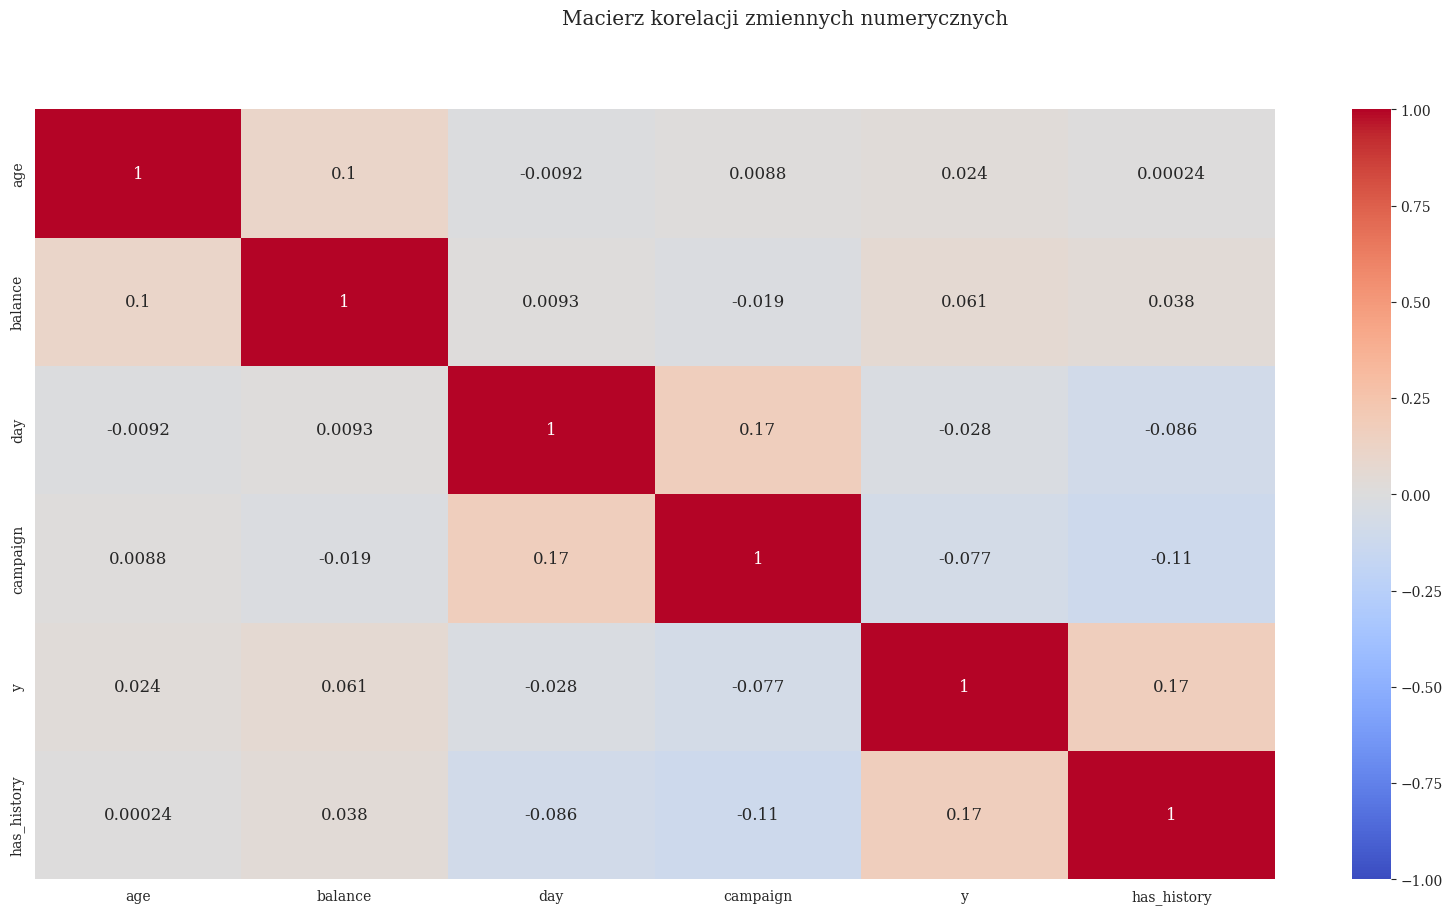

In [114]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.suptitle('Macierz korelacji zmiennych numerycznych')
plt.show()

Nasze zmienne numeryczne są w bardzo niewielkim stopniu skorelowane liniowo ze zmienną celu oraz z samymi sobą. Najbardziej skorelowana ze zmienną y jest nasza "sztuczna" zmienna związana z uczesnictwem klienta w poprzednich kampaniach.

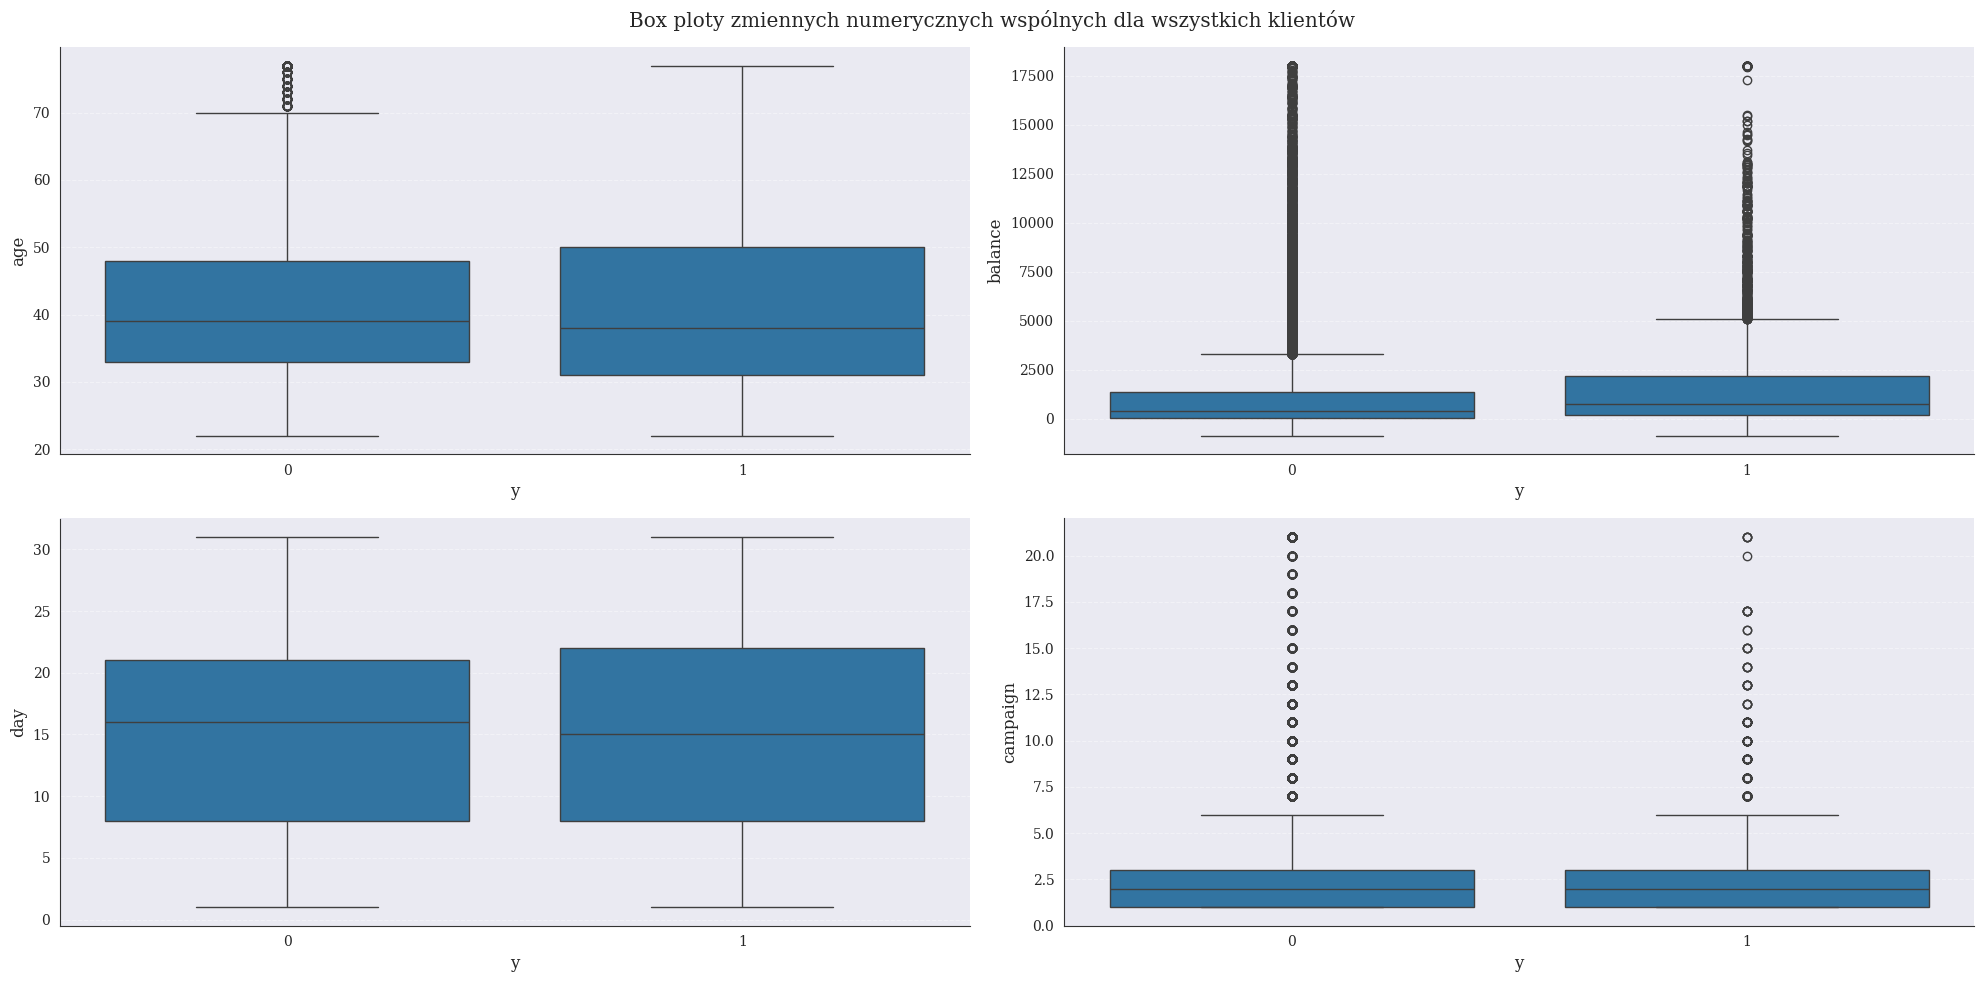

In [115]:
standard_num_cols = ['age', 'balance', 'day', 'campaign']
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for i, col in enumerate(standard_num_cols):
    sns.boxplot(x=df['y'], y=df[col], ax=axes[i])

plt.suptitle('Box ploty zmiennych numerycznych wspólnych dla wszystkich klientów')
plt.tight_layout()
plt.show()

Z boxplotów możemy odczytać ze osoby z górnych oraz dolnych przedziałów wiekowych oraz osoby o większej ilości środków na koncie były w większym stopniu zainterowane ofertą lokaty.

In [116]:
presentation_df = df.copy()
presentation_df['has_history'] = np.where(presentation_df['pdays'] == -1, 0, 1)

In [117]:
presentation_df = df.copy()
presentation_df['has_history'] = np.where(presentation_df['pdays'] == -1, 'no', 'yes')

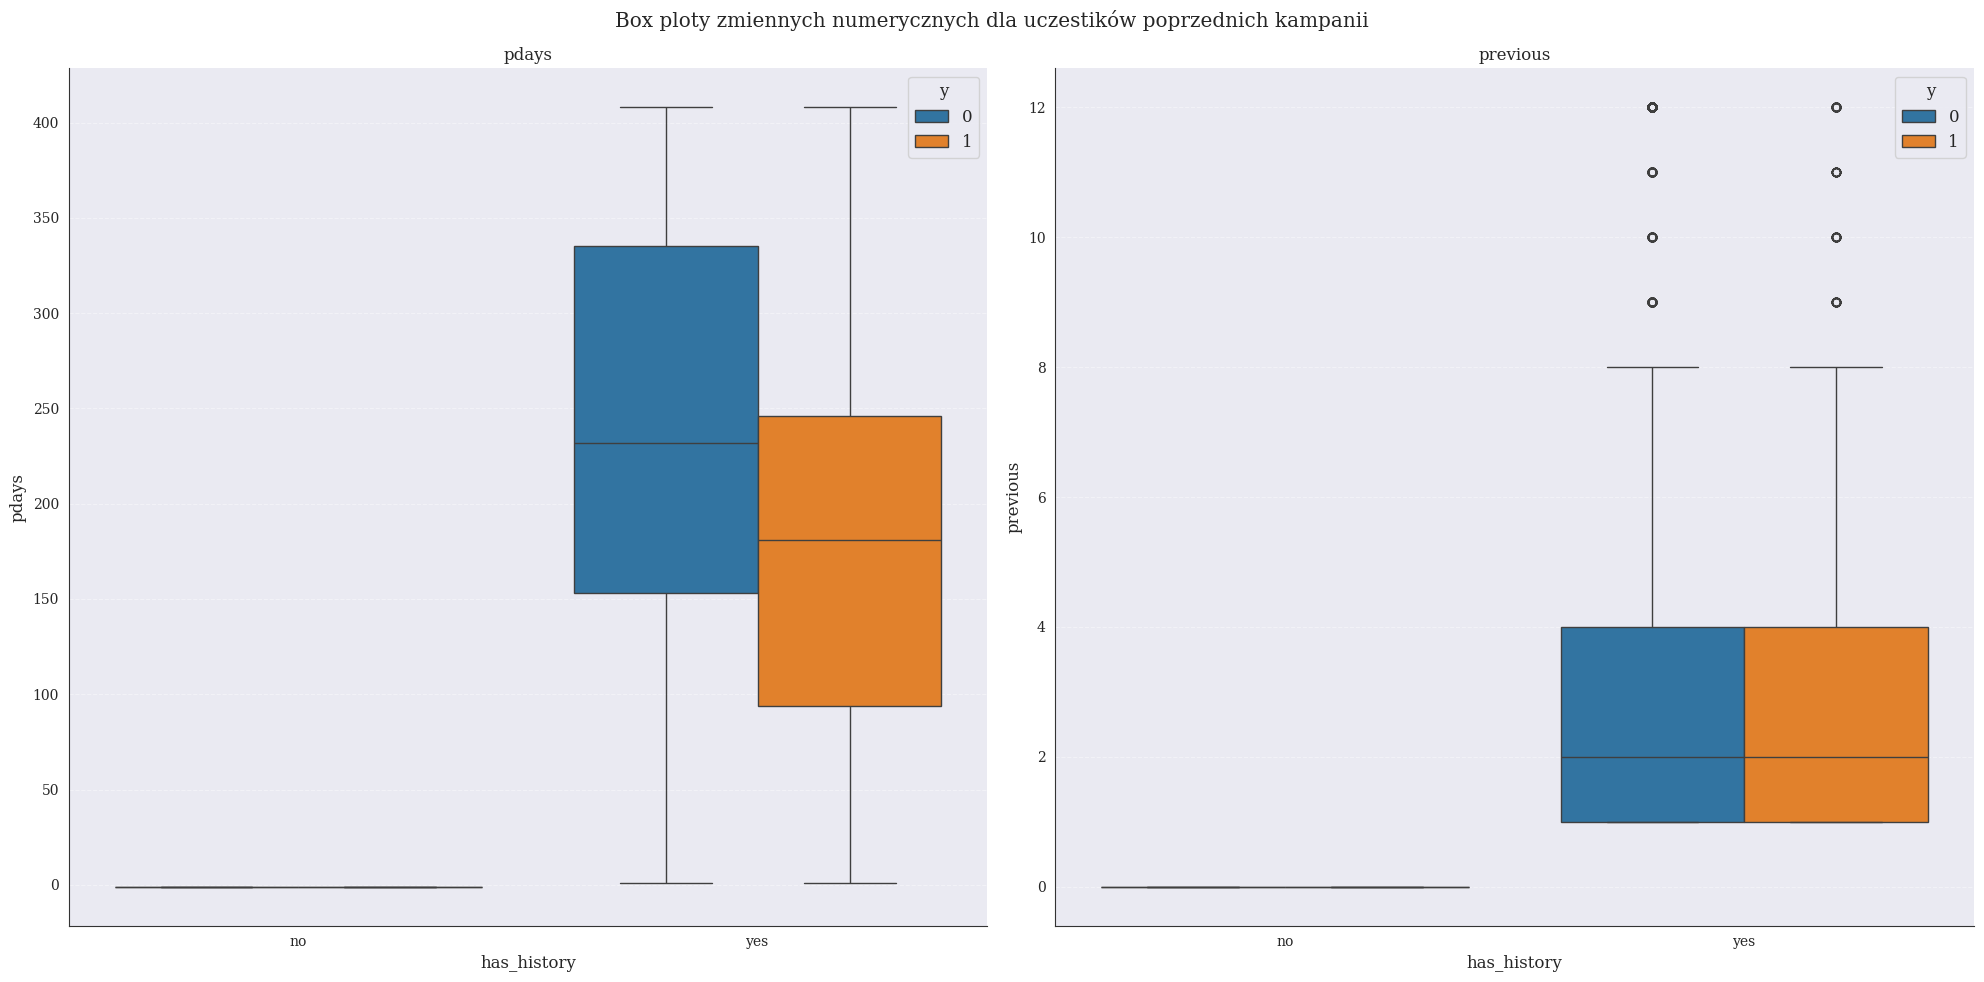

In [118]:
fig, axes = plt.subplots(1, 2)

sns.boxplot(
    data=presentation_df,
    x='has_history',
    y='pdays',
    hue='y',
    ax=axes[0]
)
axes[0].set_title('pdays')

sns.boxplot(
    data=presentation_df,
    x='has_history',
    y='previous',
    hue='y',
    ax=axes[1]
)
axes[1].set_title('previous')

plt.suptitle('Box ploty zmiennych numerycznych dla uczestików poprzednich kampanii')
plt.tight_layout()
plt.show()

In [119]:
df_with_history = presentation_df[presentation_df['has_history'] == 'yes']
cross_table = pd.crosstab(df_with_history['y'], df_with_history['previous'])
cross_table

previous,1,2,3,4,5,6,7,8,9,10,11,12
y,,,,,,,,,,,,
0,2189,1649,848,543,337,194,150,90,68,41,50,190
1,582,455,294,171,121,83,54,39,24,26,15,39


Analiza zmiennych zależnych od uczestnictwa klienta w poprzednich kampaniach wykazała, że ilość kontaktów z klientem w poprzednich akcjach promocyjnych nie miała wpływu na to czy zdecyduje się on na lokate w obecnej kampani. Z kolei analiza boxplotów dla zmiennej pdays wskazuje, że klienci chętniej korzystają z oferty, jeśli bank ponawia do nich kontakt po około pół roku. Dla dłużeszego okresu bank staje się kolejnym anonimowym telemarketerem,  którego produktu klienci nie dażą tak dużym zainteresowaniem.

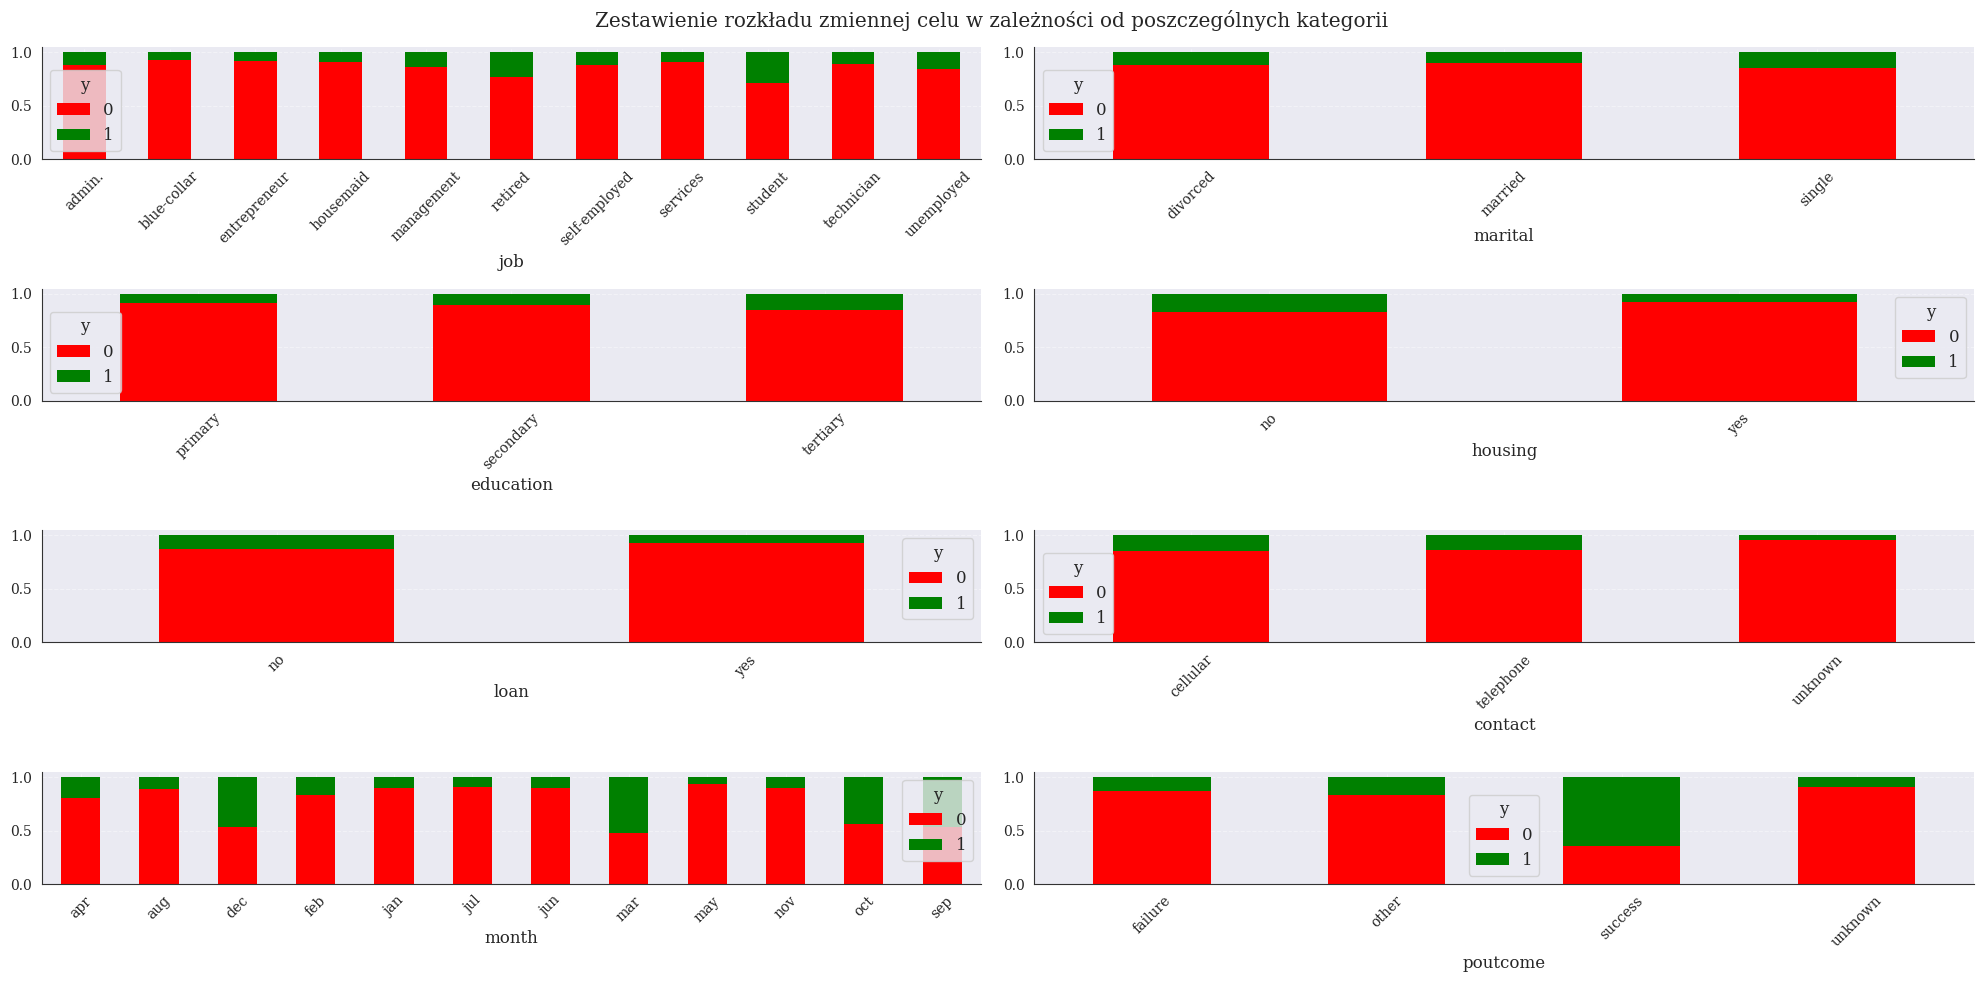

In [120]:
fig, axes = plt.subplots(4, 2)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cross_table = pd.crosstab(df[col], df['y'])
    normed_cross_table = cross_table.div(cross_table.sum(axis=1), axis=0).round(3)
    normed_cross_table.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=["red", "green"]
    )
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Zestawienie rozkładu zmiennej celu w zależności od poszczególnych kategorii')
plt.tight_layout()
plt.show()

Akcja marketingowa miała szczególnie wysoki współczynik konwersji:
- wśród studentów i osób na emeryturze
- wśród osób bez kredytu mieszkaniowego
- wśród klientów, którzy skorzystali z oferty lokaty we wcześniejszej kampanii
- w czasie marcowych, wrześniowych, październikowych i grudniowych kampanii - należy jednak mieć na uwadze, że były tymi o najmniejszej liczności w badanej próbie, więc zależność ta może być złudna

### 2.3. *Wizualizacje zaawansowane*

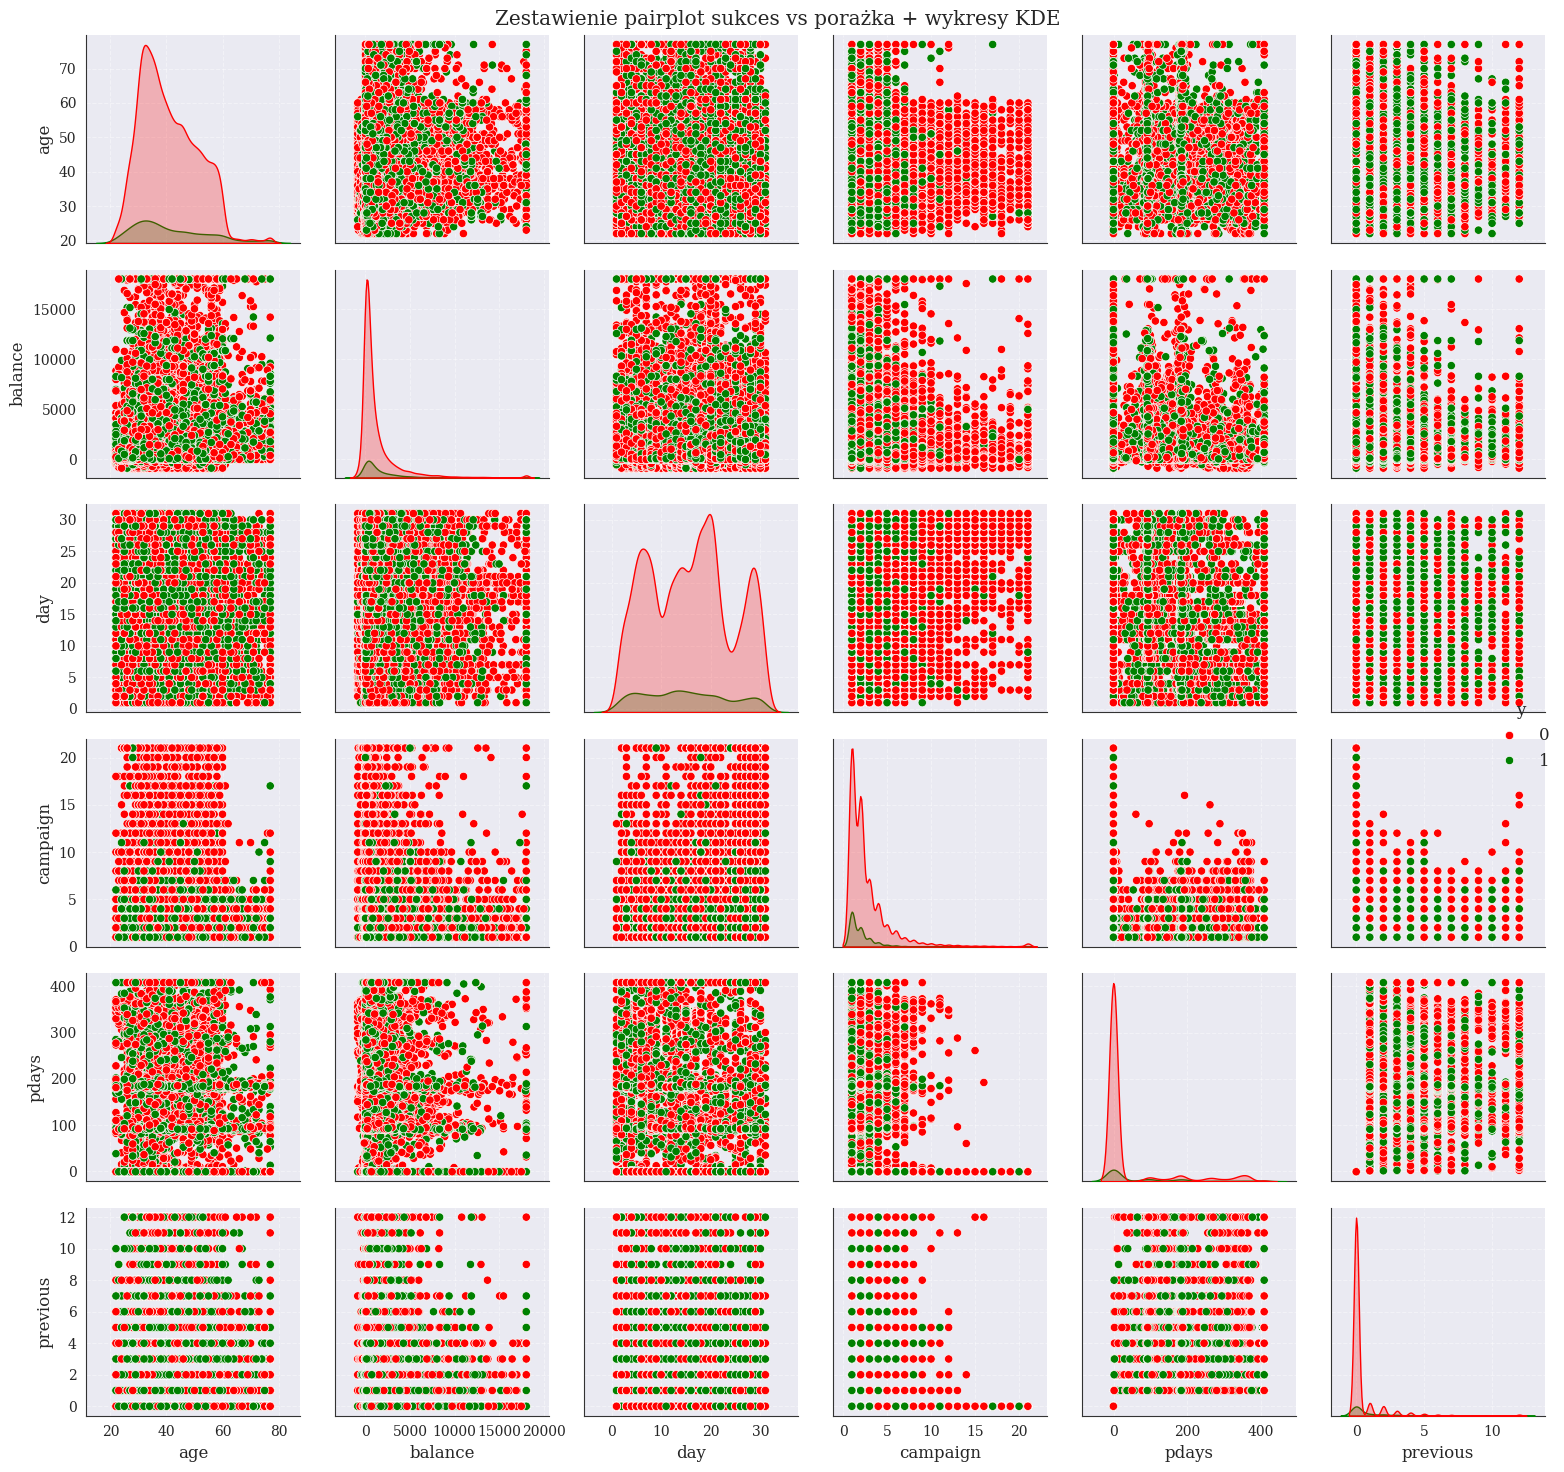

In [121]:
sns.pairplot(
    df[num_cols],
    hue='y',
    diag_kind='kde',
    palette=['red', 'green']
)
plt.suptitle('Zestawienie pairplot sukces vs porażka + wykresy KDE')
plt.tight_layout()
plt.show() #on sie w końcu wegeneruje, spokojnie

Z wykresów bardzo dokładnie widać, że przy dużych ilościach kontaków z klientem (>10) klient bardzo rzadko decyduje się na skorzystanie z oferty. Natomiast wykresy gęstości nie wnoszą zbyt dużo nowych informacji, bo kształty KDE dla 0 i 1 są podobne - różnią się jedynie skalą

In [122]:
campaign_grouped = df.groupby('campaign').y.agg(
    clients='count',
    converssion_coef='mean'
).reset_index()

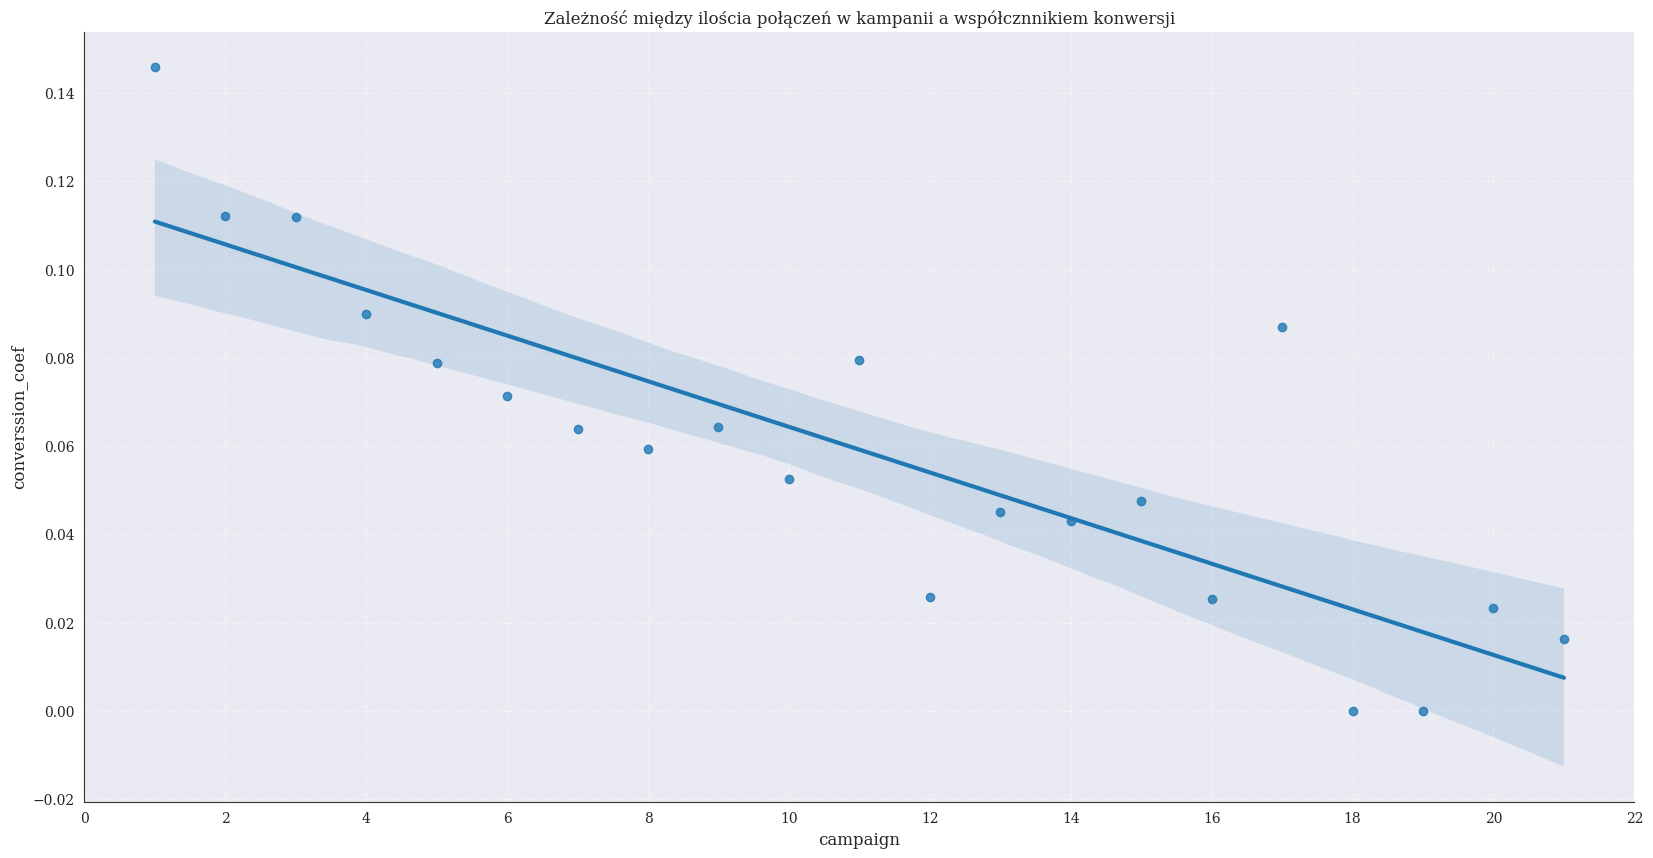

In [123]:
ax = sns.regplot(
    data=campaign_grouped,
    x='campaign',
    y='converssion_coef'
)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.title('Zależność między ilościa połączeń w kampanii a współcznnikiem konwersji')
plt.show()

Współcznnik konwersji maleje z grubsza liniowo wraz ze wzrostem liczby kontaktów z klientem w bieżącej kampanii

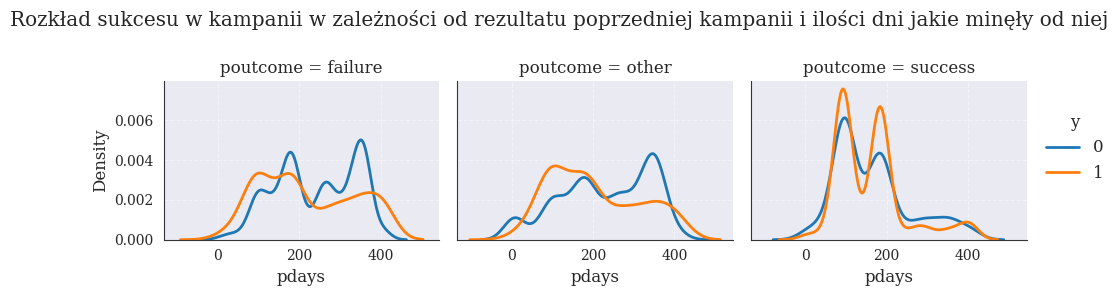

In [125]:
presentation_df = presentation_df[presentation_df['has_history'] == 'yes']
g = sns.FacetGrid(
    data=presentation_df,
    col='poutcome',
    hue='y'
)
g.map(sns.kdeplot, 'pdays', warn_singular=False)
g.add_legend()

plt.suptitle('Rozkład sukcesu w kampanii w zależności od rezultatu poprzedniej kampanii i ilości dni jakie minęły od niej')
plt.tight_layout()
plt.show()

Niezależnie od scenariusza w poprzedniej kampanii, szczyty prawdopodobieństwa konwersji kumulują się w przedziale od 100 do 200 dni. Po tym okresie prawdopodbieństwo drastycznie spada.

### 2.4 *WNIOSKI PO EDA*

Ze względu na brak istostnej informacji jaką niesie zmienna previous, decydujeny się usunąć ją z naszych danych.
Taki zagieg pozwoli zbudować model oszczędny i odporny na przeuczenie. Ponadto zidentyfikowaliśmy kluczowe, nieliniowe zależności: optymalny interwał ponownego kontaktu (3-6 miesięcy), duże zainterowanie wśród klientów, którzy poprzednio skorzystali już z oferty, negatywny wpływ nadmiernej liczby prób połączeń oraz specyficzne interakcje demograficzne,jak szczególne zainerowanie ofertą wśród młodych dorosłych oraz seniorów.

In [126]:
df.drop(columns='previous', inplace=True)